In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Load datawrangling_train.parquet
df_train = pd.read_parquet('datawrangling_train.parquet')

# Load datawrangling_test.parquet
df_test = pd.read_parquet('datawrangling_test.parquet')

def convert_to_category(df):
    df["condominiumCoverageTypeCode"] = df["condominiumCoverageTypeCode"].astype("category")
    df["ratedFloodZone"] = df["ratedFloodZone"].astype("category")
    df["numberOfFloorsInInsuredBuilding"] = df["numberOfFloorsInInsuredBuilding"].astype("category")
    df["occupancyType"] = df["occupancyType"].astype("category")
    df["rateMethod"] = df["rateMethod"].astype("category")
    df["nfipRatedCommunityNumber"] = df["nfipRatedCommunityNumber"].astype("category")
    df["nfipCommunityNumberCurrent"] = df["nfipCommunityNumberCurrent"].astype("category")
    df["propertyState"] = df["propertyState"].astype("category")
    df["reportedZipCode"] = df["reportedZipCode"].astype("category")
convert_to_category(df_train)
convert_to_category(df_test)

print("datawrangling_train.parquet head:")
display(df_train.head())

print("datawrangling_test.parquet head:")
display(df_test.head())

datawrangling_train.parquet head:


,agricultureStructureIndicator,condominiumCoverageTypeCode,construction,elevatedBuildingIndicator,federalPolicyFee,ratedFloodZone,hfiaaSurcharge,houseOfWorshipIndicator,nonProfitIndicator,numberOfFloorsInInsuredBuilding,...,tenantIndicator,stateOwnedIndicator,mandatoryPurchaseFlag,nfipRatedCommunityNumber,nfipCommunityNumberCurrent,programTypeIndicator,propertyState,reportedZipCode,latitude,longitude
0,False,N,False,True,13,C,0,False,False,1.0,...,False,False,False,090069,090069,False,CT,06475,41.3,-72.4
1,False,N,False,False,35,AE,0,False,False,2.0,...,False,False,False,390006,390006,False,OH,45801,40.8,-84.1
2,False,N,False,False,13,X,0,False,False,5.0,...,False,False,False,125092,125092,False,FL,32754,28.7,-80.9
3,False,N,False,False,35,AE,0,False,False,1.0,...,False,False,False,400246,400246,False,OK,73075,34.7,-97.2
4,False,N,False,False,13,X,0,False,False,2.0,...,False,False,False,060415,060415,False,CA,93015,34.4,-118.9


datawrangling_test.parquet head:


,agricultureStructureIndicator,condominiumCoverageTypeCode,construction,elevatedBuildingIndicator,federalPolicyFee,ratedFloodZone,hfiaaSurcharge,houseOfWorshipIndicator,nonProfitIndicator,numberOfFloorsInInsuredBuilding,...,tenantIndicator,stateOwnedIndicator,mandatoryPurchaseFlag,nfipRatedCommunityNumber,nfipCommunityNumberCurrent,programTypeIndicator,propertyState,reportedZipCode,latitude,longitude
0,False,N,False,False,35,AE,0,False,False,2.0,...,False,False,False,120643,120643,False,FL,33012,25.8,-80.3
1,False,N,False,False,35,AE,0,False,False,2.0,...,False,False,False,370048,370048,False,NC,28557,34.7,-76.8
2,False,N,False,True,35,AE,0,False,False,3.0,...,False,False,False,370078,370078,False,NC,27927,36.3,-75.8
3,False,N,False,True,35,AE,0,False,False,3.0,...,False,False,False,370170,370170,False,NC,28449,34.0,-77.9
4,False,N,False,False,13,X,0,False,False,3.0,...,False,False,False,340399,340399,False,NJ,07508,40.9,-74.2


In [2]:
print("datawrangling_train.parquet dtypes:")
display(df_train.dtypes)

print("datawrangling_test.parquet dtypes:")
display(df_test.dtypes)

datawrangling_train.parquet dtypes:


,0
agricultureStructureIndicator,bool
condominiumCoverageTypeCode,category
construction,bool
elevatedBuildingIndicator,bool
federalPolicyFee,int16
ratedFloodZone,category
hfiaaSurcharge,int16
houseOfWorshipIndicator,bool
nonProfitIndicator,bool
numberOfFloorsInInsuredBuilding,category


datawrangling_test.parquet dtypes:


,0
agricultureStructureIndicator,bool
condominiumCoverageTypeCode,category
construction,bool
elevatedBuildingIndicator,bool
federalPolicyFee,int16
ratedFloodZone,category
hfiaaSurcharge,int16
houseOfWorshipIndicator,bool
nonProfitIndicator,bool
numberOfFloorsInInsuredBuilding,category


In addition to encoding `ratedFloodZone` (X, AE), I'll also include `elevatedBuildingIndicator`, `postFIRMConstructionIndicator`, `primaryResidenceIndicator`, and `mandatoryPurchaseFlag` because they are the most balanced indicators.

In [3]:
# Define the columns to keep
keep_indicators = [
    'elevatedBuildingIndicator',
    'postFIRMConstructionIndicator',
    'primaryResidenceIndicator',
    'mandatoryPurchaseFlag'
]

def process_categorical_data(df):
    # One-hot encode ratedFloodZone for 'X' and 'AE'
    # We filter categories first to ensure get_dummies only creates columns for X and AE
    dummies = pd.get_dummies(df['ratedFloodZone'])
    dummies = dummies[['X', 'AE']].rename(columns={'X': 'ratedFloodZone_X', 'AE': 'ratedFloodZone_AE'})

    # Select numerical and datetime columns
    numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
    datetime_cols = df.select_dtypes(include=['datetime', 'datetime64']).columns.tolist()

    # Combine numerical columns, datetime columns, the indicators we want to keep, and the new dummies
    cols_to_keep = numerical_cols + datetime_cols + keep_indicators
    df_processed = pd.concat([df[cols_to_keep], dummies], axis=1)

    return df_processed

# Apply the processing to both dataframes
df_train = process_categorical_data(df_train)
df_test = process_categorical_data(df_test)

print("Columns in processed train set:", df_train.columns.tolist())
display(df_train.head())

Columns in processed train set: ['federalPolicyFee', 'hfiaaSurcharge', 'policyCost', 'policyCount', 'totalBuildingInsuranceCoverage', 'totalContentsInsuranceCoverage', 'totalInsurancePremiumOfThePolicy', 'reserveFundAssessment', 'latitude', 'longitude', 'originalConstructionDate', 'originalNBDate', 'policyEffectiveDate', 'policyTerminationDate', 'elevatedBuildingIndicator', 'postFIRMConstructionIndicator', 'primaryResidenceIndicator', 'mandatoryPurchaseFlag', 'ratedFloodZone_X', 'ratedFloodZone_AE']


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,reserveFundAssessment,latitude,longitude,originalConstructionDate,originalNBDate,policyEffectiveDate,policyTerminationDate,elevatedBuildingIndicator,postFIRMConstructionIndicator,primaryResidenceIndicator,mandatoryPurchaseFlag,ratedFloodZone_X,ratedFloodZone_AE
0,13,0,346,1,250000,100000,333,0,41.3,-72.4,1959-01-01,2008-03-20,2009-03-20,2010-03-20,True,False,True,False,False,False
1,35,0,295,1,31000,0,260,0,40.8,-84.1,1954-01-01,2005-05-13,2009-05-13,2010-05-13,False,False,False,False,False,True
2,13,0,148,1,30000,12000,135,0,28.7,-80.9,1974-10-10,2005-06-13,2009-06-13,2010-06-13,False,False,True,False,True,False
3,35,0,413,1,39900,0,378,0,34.7,-97.2,1958-01-01,2003-01-12,2009-01-12,2010-01-12,False,False,True,False,False,True
4,13,0,348,1,250000,100000,335,0,34.4,-118.9,2002-01-01,2009-12-12,2009-12-12,2010-12-12,False,True,True,False,True,False


I think I need to convert datetime data into numerical data.

In [4]:
# Identify datetime columns
datetime_cols = df_train.select_dtypes(include=['datetime64']).columns.tolist()

# Convert datetime columns to numerical (Unix timestamps in seconds)
for col in datetime_cols:
    df_train[col] = pd.to_numeric(df_train[col]) / 10**9
    df_test[col] = pd.to_numeric(df_test[col]) / 10**9

print(f"Converted columns: {datetime_cols}")
display(df_train[datetime_cols].head())

Converted columns: ['originalConstructionDate', 'originalNBDate', 'policyEffectiveDate', 'policyTerminationDate']


,originalConstructionDate,originalNBDate,policyEffectiveDate,policyTerminationDate
0,-3.471552e+08,1.205971e+09,1.237507e+09,1.269043e+09
1,-5.049216e+08,1.115942e+09,1.242173e+09,1.273709e+09
2,1.505952e+08,1.118621e+09,1.244851e+09,1.276387e+09
3,-3.786912e+08,1.042330e+09,1.231718e+09,1.263254e+09
4,1.009843e+09,1.260576e+09,1.260576e+09,1.292112e+09


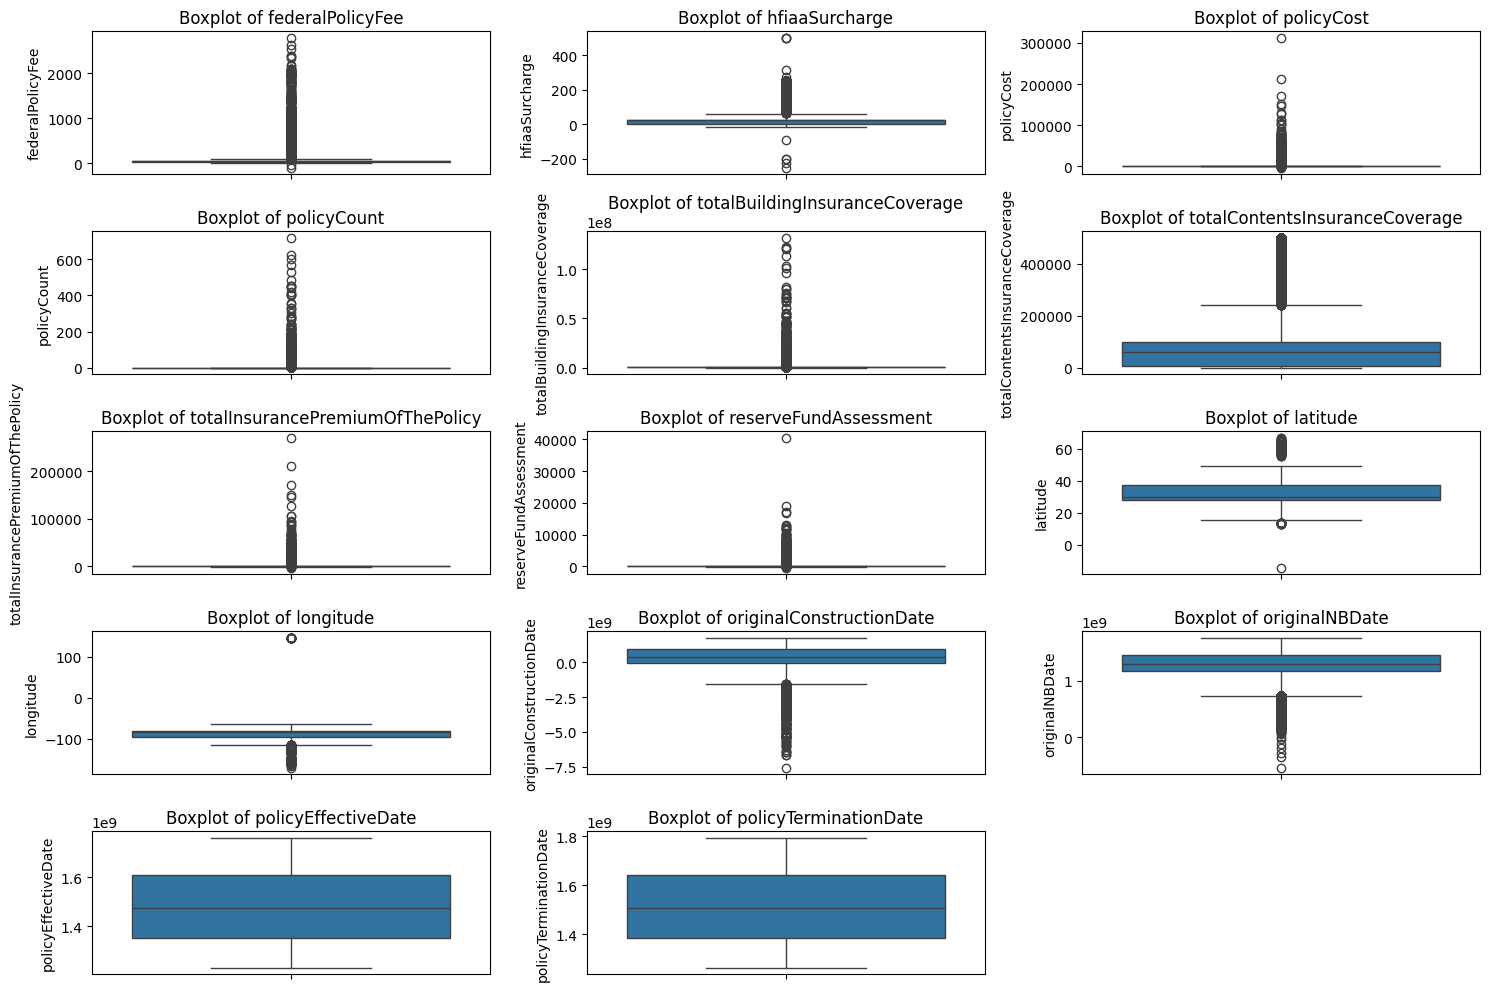

In [5]:
# Select numerical columns for boxplots
numerical_cols = df_train.select_dtypes(include=['number']).columns

# Set up the figure
plt.figure(figsize=(15, 10))

# Create boxplots for each numerical column
for i, col in enumerate(numerical_cols, 1):
    plt.subplot((len(numerical_cols) + 2) // 3, 3, i)
    sns.boxplot(y=df_train[col])
    plt.title(f'Boxplot of {col}')

plt.tight_layout()
plt.show()

The financial data skew right and should be log transformed first. Some of the date data skew left and should be reflected and log transformed. Then `StandardScaler` the numerical data.

In [6]:
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Cyclical Encoding for Latitude and Longitude
def encode_coordinates(df):
    # Convert to radians
    lat_rad = np.radians(df['latitude'])
    lon_rad = np.radians(df['longitude'])

    # Project to 3D Cartesian coordinates
    df['coord_x'] = np.cos(lat_rad) * np.cos(lon_rad)
    df['coord_y'] = np.cos(lat_rad) * np.sin(lon_rad)
    df['coord_z'] = np.sin(lat_rad)

    # Drop original lat/lon as they are now represented by x, y, z
    return df.drop(['latitude', 'longitude'], axis=1)

df_train = encode_coordinates(df_train)
df_test = encode_coordinates(df_test)

# 2. Define columns for skewness transformation
# Removed 'policyCost' from here so it is not log transformed
right_skew_cols = [
    'federalPolicyFee',
    'hfiaaSurcharge',
    'policyCount',
    'totalBuildingInsuranceCoverage',
    'totalContentsInsuranceCoverage',
    'totalInsurancePremiumOfThePolicy',
    'reserveFundAssessment'
]

left_skew_cols = [
    'originalConstructionDate',
    'originalNBDate'
]

# Handle Right Skew
for col in right_skew_cols:
    min_val = min(df_train[col].min(), df_test[col].min())
    if min_val < 0:
        shift = abs(min_val)
        df_train[col] = df_train[col] + shift
        df_test[col] = df_test[col] + shift
    df_train[col] = np.log1p(df_train[col])
    df_test[col] = np.log1p(df_test[col])

# Handle Left Skew (Reflect and Log)
for col in left_skew_cols:
    max_val = max(df_train[col].max(), df_test[col].max())
    df_train[col] = np.log1p((max_val + 1) - df_train[col])
    df_test[col] = np.log1p((max_val + 1) - df_test[col])

# 3. StandardScaler all numerical data EXCEPT policyCost
numerical_cols = df_train.select_dtypes(include=['number']).columns.tolist()
if 'policyCost' in numerical_cols:
    numerical_cols.remove('policyCost')

scaler = StandardScaler()

df_train[numerical_cols] = scaler.fit_transform(df_train[numerical_cols])
df_test[numerical_cols] = scaler.transform(df_test[numerical_cols])

print("Cyclical coordinate encoding, skewness correction, and Standard Scaling complete. 'policyCost' was NOT transformed.")
display(df_train.head())

Cyclical coordinate encoding, skewness correction, and Standard Scaling complete. 'policyCost' was NOT transformed.


,federalPolicyFee,hfiaaSurcharge,policyCost,policyCount,totalBuildingInsuranceCoverage,totalContentsInsuranceCoverage,totalInsurancePremiumOfThePolicy,reserveFundAssessment,originalConstructionDate,originalNBDate,...,policyTerminationDate,elevatedBuildingIndicator,postFIRMConstructionIndicator,primaryResidenceIndicator,mandatoryPurchaseFlag,ratedFloodZone_X,ratedFloodZone_AE,coord_x,coord_y,coord_z
0,-1.095671,-0.647591,346,-0.096999,0.287760,0.648721,-0.544076,-0.538643,0.919092,0.518824,...,-1.625521,True,False,True,False,False,False,1.108277,1.292637,1.544664
1,-0.164325,-0.647591,295,-0.096999,-0.840678,-1.781678,-0.656198,-0.538643,1.036053,0.736138,...,-1.594654,False,False,False,False,False,True,0.250586,0.828012,1.463924
2,-1.095671,-0.647591,148,-0.096999,-0.858404,0.201146,-0.855267,-0.538643,0.482422,0.730122,...,-1.576934,False,False,True,False,True,False,0.600415,-0.596844,-0.660945
3,-0.164325,-0.647591,413,-0.096999,-0.704245,-1.781678,-0.476393,-0.538643,0.943158,0.892399,...,-1.663820,False,False,True,False,False,True,-0.788061,0.038554,0.431639
4,-1.095671,-0.647591,348,-0.096999,0.287760,0.648721,-0.541045,-0.538643,-0.756333,0.369141,...,-1.472899,False,True,True,False,True,False,-2.486378,1.213791,0.378731


In [7]:
df_train.to_parquet('preprocessing_train.parquet', index=False)
df_test.to_parquet('preprocessing_test.parquet', index=False)

print("df_train saved to preprocessing_train.parquet")
print("df_test saved to preprocessing_test.parquet")

df_train saved to preprocessing_train.parquet
df_test saved to preprocessing_test.parquet
